In [ ]:
import pandas as pd
df = pd.read_csv('/content/Metro_Interstate_Traffic_Volume.csv')
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [ ]:
df.isnull().sum()

,0
traffic_volume,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0


Handling missing values

In [ ]:
df["holiday"] = df["holiday"].fillna("None")
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,None,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,None,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,None,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,None,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,None,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [ ]:
df.describe()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,3259.818355,281.205870,0.334264,0.000222,49.362231
std,1986.860670,13.338232,44.789133,0.008168,39.015750
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1193.000000,272.160000,0.000000,0.000000,1.000000
50%,3380.000000,282.450000,0.000000,0.000000,64.000000
75%,4933.000000,291.806000,0.000000,0.000000,90.000000
max,7280.000000,310.070000,9831.300000,0.510000,100.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   traffic_volume       48204 non-null  int64  
 1   holiday              48204 non-null  object 
 2   temp                 48204 non-null  float64
 3   rain_1h              48204 non-null  float64
 4   snow_1h              48204 non-null  float64
 5   clouds_all           48204 non-null  int64  
 6   weather_main         48204 non-null  object 
 7   weather_description  48204 non-null  object 
 8   date_time            48204 non-null  object 
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   traffic_volume       48204 non-null  int64         
 1   holiday              48204 non-null  object        
 2   temp                 48204 non-null  float64       
 3   rain_1h              48204 non-null  float64       
 4   snow_1h              48204 non-null  float64       
 5   clouds_all           48204 non-null  int64         
 6   weather_main         48204 non-null  object        
 7   weather_description  48204 non-null  object        
 8   date_time            48204 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


Range of the dataset

In [ ]:
date_time = df['date_time']

In [ ]:
start_date = date_time.min()
print(start_date)

2012-10-02 09:00:00


In [ ]:
end_date = date_time.max()
print(end_date)

2018-09-30 23:00:00


Frequency of the records

In [ ]:
df = df.sort_values("date_time")

In [ ]:
df["time_diff"] = df["date_time"].diff()
df["time_diff"].value_counts().head()

,count
time_diff,
0 days 01:00:00,37986
0 days 00:00:00,7629
0 days 02:00:00,2192
0 days 03:00:00,201
0 days 04:00:00,59


#Analytical Questions

Does traffic volume increase or decrrease over the years ?

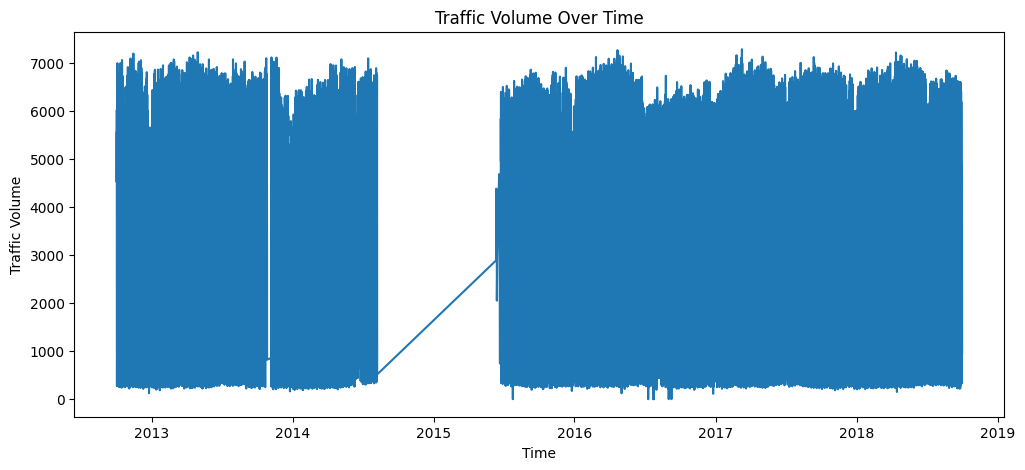

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["date_time"], df["traffic_volume"])
plt.title("Traffic Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()

How does holidays impact traffic volumes?

In [ ]:
# Creating a binary variable or 0 not holiday and 1 for is holiday
df["holiday"] = df["holiday"].fillna("None")
df["is_holiday"] = (df["holiday"] != "None").astype(int)

In [ ]:
holiday_avg = df.groupby("is_holiday")["traffic_volume"].mean()
holiday_avg

,traffic_volume
is_holiday,
0,3262.852170
1,865.442623


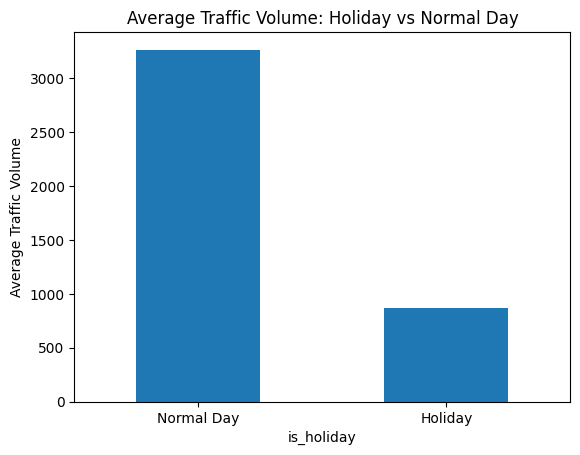

In [ ]:
import matplotlib.pyplot as plt

holiday_avg.plot(kind="bar")
plt.xticks([0,1], ["Normal Day", "Holiday"], rotation=0)
plt.title("Average Traffic Volume: Holiday vs Normal Day")
plt.ylabel("Average Traffic Volume")
plt.show()

The graph shows that traffic volume is significantly higher on a mormal day than on holidays. This makes sense because on holidays a lot of people have already traveled to their homes to celebrate and only a few people go to work.

Does a 24-hour Moving Average Reveal Underlying Trends in Traffic Volume?

In [ ]:
df['ma_24'] = df['traffic_volume'].rolling(window=24).mean()
df['ma_168'] = df['traffic_volume'].rolling(window=168).mean()  # 7 days

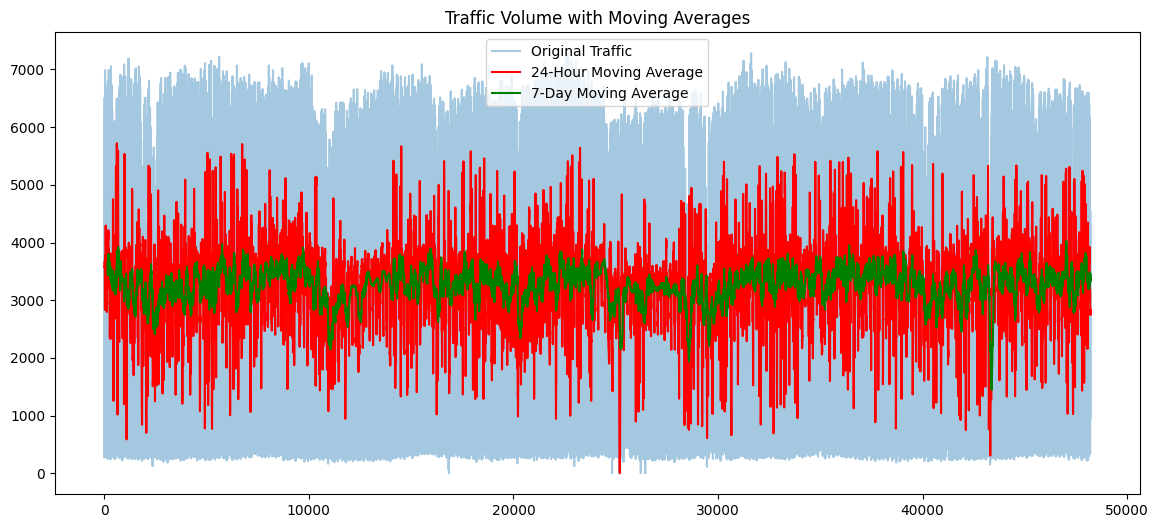

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['traffic_volume'], alpha=0.4, label='Original Traffic')
plt.plot(df.index, df['ma_24'], color='red', label='24-Hour Moving Average')
plt.plot(df.index, df['ma_168'], color='green', label='7-Day Moving Average')

plt.title("Traffic Volume with Moving Averages")
plt.legend()
plt.show()

Is current traffic volume influenced by traffic in previous hours? (Lag Analysis)

In [ ]:
# Create lag features
df['lag_1'] = df['traffic_volume'].shift(1)      # 1 hour before
df['lag_24'] = df['traffic_volume'].shift(24)    # 24 hours before

# Drop NaNs caused by shifting
lag_df = df[['traffic_volume', 'lag_1', 'lag_24']].dropna()

In [ ]:
# Correlation with Lag Features
lag_corr = lag_df.corr()

print("Correlation with Current Traffic Volume:")
print(lag_corr['traffic_volume'])

Correlation with Current Traffic Volume:
traffic_volume    1.000000
lag_1             0.912708
lag_24            0.369515
Name: traffic_volume, dtype: float64


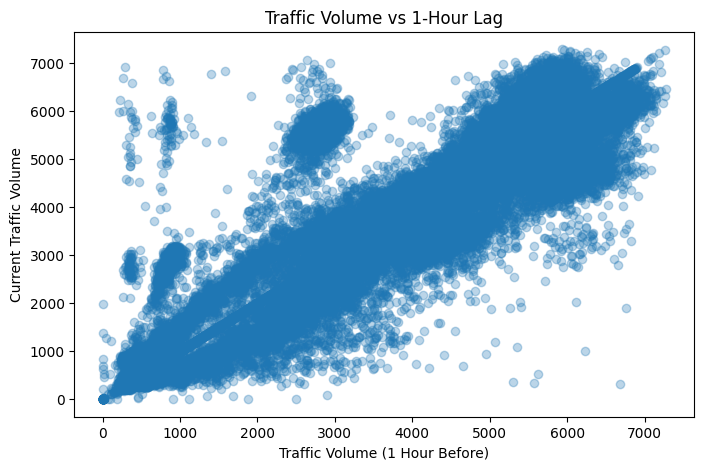

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(lag_df['lag_1'], lag_df['traffic_volume'], alpha=0.3)
plt.title("Traffic Volume vs 1-Hour Lag")
plt.xlabel("Traffic Volume (1 Hour Before)")
plt.ylabel("Current Traffic Volume")
plt.show()

## Create Monthly Lag Feature

### Subtask:
Create a new lagged feature, `lag_720`, representing the traffic volume from approximately 30 days (720 hours) prior. This will help us understand monthly patterns.


In [ ]:
df['lag_720'] = df['traffic_volume'].shift(720)
df.head()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all,date_time,is_holiday,ma_24,ma_168,lag_1,...,weather_description_smoke,weather_description_snow,weather_description_thunderstorm,weather_description_thunderstorm with drizzle,weather_description_thunderstorm with heavy rain,weather_description_thunderstorm with light drizzle,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain,lag_720
0,5545,288.28,0.0,0.0,40,2012-10-02 09:00:00,0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,NaN
1,4516,289.36,0.0,0.0,75,2012-10-02 10:00:00,0,NaN,NaN,5545.0,...,False,False,False,False,False,False,False,False,False,NaN
2,4767,289.58,0.0,0.0,90,2012-10-02 11:00:00,0,NaN,NaN,4516.0,...,False,False,False,False,False,False,False,False,False,NaN
3,5026,290.13,0.0,0.0,90,2012-10-02 12:00:00,0,NaN,NaN,4767.0,...,False,False,False,False,False,False,False,False,False,NaN
4,4918,291.14,0.0,0.0,75,2012-10-02 13:00:00,0,NaN,NaN,5026.0,...,False,False,False,False,False,False,False,False,False,NaN


In [ ]:
lag_720_df = df[['traffic_volume', 'lag_720']].dropna()
lag_720_corr = lag_720_df.corr()

print("Correlation with Current Traffic Volume and 720-Hour Lag:")
print(lag_720_corr['traffic_volume'])

Correlation with Current Traffic Volume and 720-Hour Lag:
traffic_volume    1.000000
lag_720           0.020911
Name: traffic_volume, dtype: float64


**Reasoning**:
To visually represent the relationship between current traffic volume and the 720-hour lagged traffic volume, I will generate a scatter plot using the `lag_720_df` DataFrame.



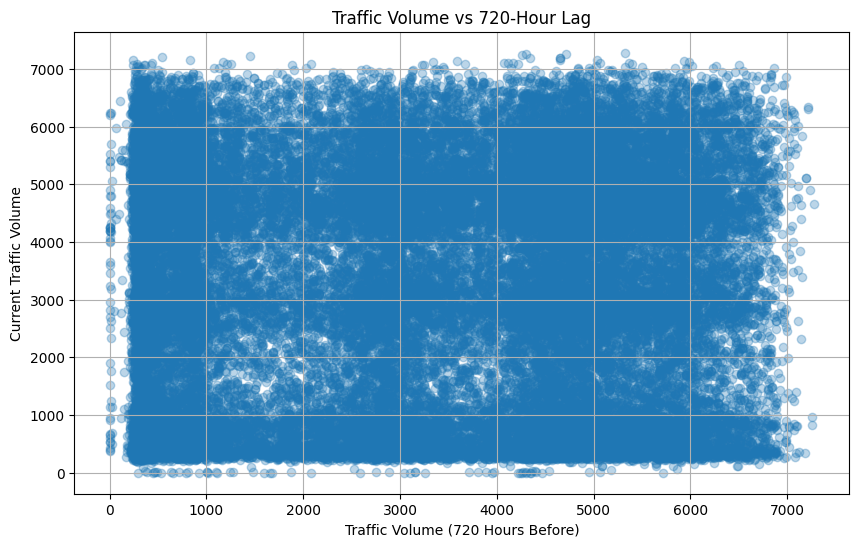

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(lag_720_df['lag_720'], lag_720_df['traffic_volume'], alpha=0.3)
plt.title("Traffic Volume vs 720-Hour Lag")
plt.xlabel("Traffic Volume (720 Hours Before)")
plt.ylabel("Current Traffic Volume")
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings
*   A new feature, `lag_720`, was successfully created, representing the traffic volume from 720 hours (approximately 30 days) prior.
*   The correlation coefficient between the current `traffic_volume` and `lag_720` was found to be approximately 0.020911.
*   This correlation indicates a very weak positive linear relationship between the current traffic volume and the traffic volume from 30 days prior.
*   A scatter plot visualization of the relationship between current traffic volume and `lag_720` visually supported the low correlation, showing no distinct pattern or trend.

### Insights or Next Steps
*   The extremely low correlation suggests that a direct lag of 30 days in traffic volume has negligible predictive power for current traffic flow, indicating that monthly patterns might not be a strong standalone factor for forecasting.
*   Future analysis should investigate other lag periods, such as 24-hour (daily) or 168-hour (weekly) lags, which are more likely to capture significant temporal dependencies in traffic patterns.


## Create Weekly Lag Feature

### Subtask:
Create a new lagged feature, `lag_168`, representing the traffic volume from 168 hours (7 days) prior.


In [ ]:
df['lag_168'] = df['traffic_volume'].shift(168)
df.head()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all,date_time,is_holiday,ma_24,ma_168,lag_1,...,weather_description_snow,weather_description_thunderstorm,weather_description_thunderstorm with drizzle,weather_description_thunderstorm with heavy rain,weather_description_thunderstorm with light drizzle,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain,lag_720,lag_168
0,5545,288.28,0.0,0.0,40,2012-10-02 09:00:00,0,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,NaN,NaN
1,4516,289.36,0.0,0.0,75,2012-10-02 10:00:00,0,NaN,NaN,5545.0,...,False,False,False,False,False,False,False,False,NaN,NaN
2,4767,289.58,0.0,0.0,90,2012-10-02 11:00:00,0,NaN,NaN,4516.0,...,False,False,False,False,False,False,False,False,NaN,NaN
3,5026,290.13,0.0,0.0,90,2012-10-02 12:00:00,0,NaN,NaN,4767.0,...,False,False,False,False,False,False,False,False,NaN,NaN
4,4918,291.14,0.0,0.0,75,2012-10-02 13:00:00,0,NaN,NaN,5026.0,...,False,False,False,False,False,False,False,False,NaN,NaN


**Reasoning**:
Now that the `lag_168` feature has been created, I will calculate the correlation between the current `traffic_volume` and the new `lag_168` feature to understand their linear relationship. I will create a temporary DataFrame `lag_168_df` to handle `NaN` values before calculating the correlation and print the correlation of `traffic_volume` with `lag_168`.



In [ ]:
lag_168_df = df[['traffic_volume', 'lag_168']].dropna()
lag_168_corr = lag_168_df.corr()

print("Correlation with Current Traffic Volume and 168-Hour Lag:")
print(lag_168_corr['traffic_volume'])

Correlation with Current Traffic Volume and 168-Hour Lag:
traffic_volume    1.000000
lag_168           0.096376
Name: traffic_volume, dtype: float64


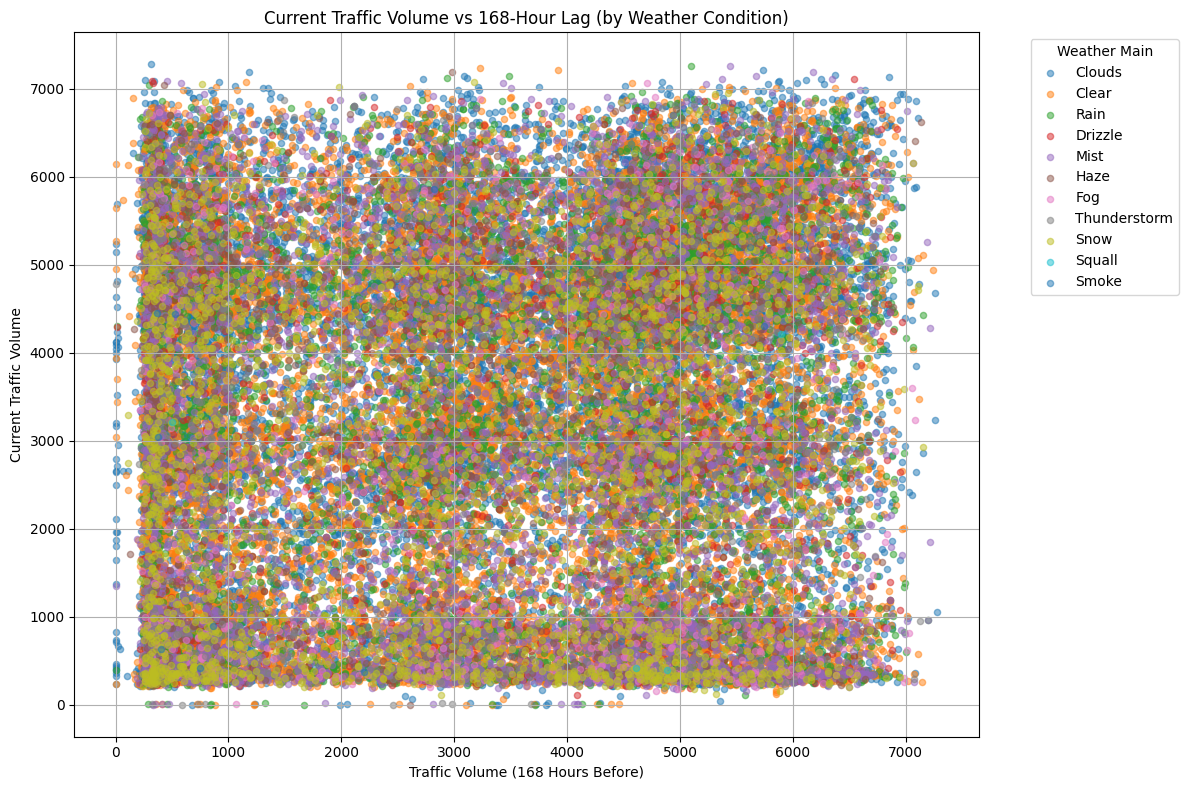

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Start with a fresh load of the data to ensure 'weather_main' is present
# and apply preprocessing steps consistent with the original notebook flow
# up to the point of one-hot encoding.
temp_df_for_plot = pd.read_csv('/content/Metro_Interstate_Traffic_Volume.csv')

# Apply necessary preprocessing steps before one-hot encoding
# (Based on cells TpWUbqQNoMj9, qhAoJZ_4AoIG, 2qVnedftJoBI, QE0pdEaRw96t)
temp_df_for_plot["holiday"] = temp_df_for_plot["holiday"].fillna("None")
temp_df_for_plot['date_time'] = pd.to_datetime(temp_df_for_plot['date_time'], format='%d-%m-%Y %H:%M')
temp_df_for_plot = temp_df_for_plot.sort_values("date_time")
temp_df_for_plot["is_holiday"] = (temp_df_for_plot["holiday"] != "None").astype(int)

# Now, add the lag_168 feature to this temporary dataframe
temp_df_for_plot['lag_168'] = temp_df_for_plot['traffic_volume'].shift(168)

# Create the plotting dataframe including 'traffic_volume', 'lag_168', and 'weather_main'
lag_168_df_with_weather = temp_df_for_plot[['traffic_volume', 'lag_168', 'weather_main']].dropna()

plt.figure(figsize=(12, 8))

# Get unique weather categories for coloring
weather_categories = lag_168_df_with_weather['weather_main'].unique()

for category in weather_categories:
    subset = lag_168_df_with_weather[lag_168_df_with_weather['weather_main'] == category]
    plt.scatter(subset['lag_168'], subset['traffic_volume'], alpha=0.5, label=category, s=20)

plt.title("Current Traffic Volume vs 168-Hour Lag (by Weather Condition)")
plt.xlabel("Traffic Volume (168 Hours Before)")
plt.ylabel("Current Traffic Volume")
plt.grid(True)
plt.legend(title='Weather Main', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Summary: Weekly Lag Analysis and Weather Impact

### Data Analysis Key Findings
*   **Correlation:** The correlation coefficient between the current `traffic_volume` and `lag_168` (traffic volume from 168 hours or 7 days prior) was found to be approximately 0.096. This indicates a weak positive linear relationship, suggesting that while weekly patterns exist, the traffic volume a week ago is not a strong predictor on its own for the current traffic volume.
*   **Scatter Plot Visualization (by Weather Condition):**
    *   The scatter plot shows a general upward trend, albeit with significant scatter, indicating that higher traffic volumes last week tend to correlate with higher traffic volumes this week, but the relationship is not strong and is heavily influenced by other factors.
    *   **Impact of Weather:** Different weather conditions are represented by distinct clusters or distributions of points:
        *   **Clear weather and Clouds:** These categories show the highest traffic volumes, with points scattered across a wide range, indicating that while weekly patterns are present, the absolute traffic volume during these conditions is generally higher.
        *   **Rain and Drizzle:** Traffic volumes appear to be slightly lower and less dispersed compared to clear or cloudy conditions, suggesting that adverse weather might reduce overall traffic or make its weekly pattern less pronounced.
        *   **Mist, Haze, Fog, Snow, Thunderstorm:** These conditions generally correspond to lower traffic volumes and a more constrained range of traffic, both for `lag_168` and current `traffic_volume`. This is expected as severe weather typically discourages travel.



# Model Training

In [ ]:
# Encoding the categorical variables
categorical_cols = ["holiday", "weather_main", "weather_description"]

# Filter out columns that are no longer present in the DataFrame
cols_to_encode_now = [col for col in categorical_cols if col in df.columns]

if cols_to_encode_now:
    df = pd.get_dummies(df, columns=cols_to_encode_now, drop_first=True)
else:
    print(f"All specified categorical columns ({', '.join(categorical_cols)}) were already encoded or are not present in the DataFrame.")

### Train Test Split

In [ ]:
# Drop 'time_diff' if it exists, as it was a timedelta type that might have caused issues or NaNs.
# Ensure all feature engineering is complete before this step.
if 'time_diff' in df.columns:
    df = df.drop('time_diff', axis=1)

# Drop any remaining rows with NaN values after all feature creation (e.g., from rolling averages or lag features)
df_cleaned = df.dropna()


train_size = int(len(df_cleaned) * 0.8)

train = df_cleaned[:train_size]
test = df_cleaned[train_size:]

X_train = train.drop(["traffic_volume", "date_time"], axis=1)
y_train = train["traffic_volume"]

X_test = test.drop(["traffic_volume", "date_time"], axis=1)
y_test = test["traffic_volume"]

### Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np # Import numpy for np.sqrt

# Diagnostic: Check for NaNs before model training
print("NaNs in X_train before fit:\n", X_train.isnull().sum()[X_train.isnull().sum() > 0])
print("NaNs in X_test before fit:\n", X_test.isnull().sum()[X_test.isnull().sum() > 0])

model1 = LinearRegression()
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

mae1 = mean_absolute_error(y_test, pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, pred1))

print("Experiment 1 - Linear Regression")
print("MAE:", mae1)
print("RMSE:", rmse1)

NaNs in X_train before fit:
 Series([], dtype: int64)
NaNs in X_test before fit:
 Series([], dtype: int64)
Experiment 1 - Linear Regression
MAE: 489.9502606043217
RMSE: 684.4204727449036


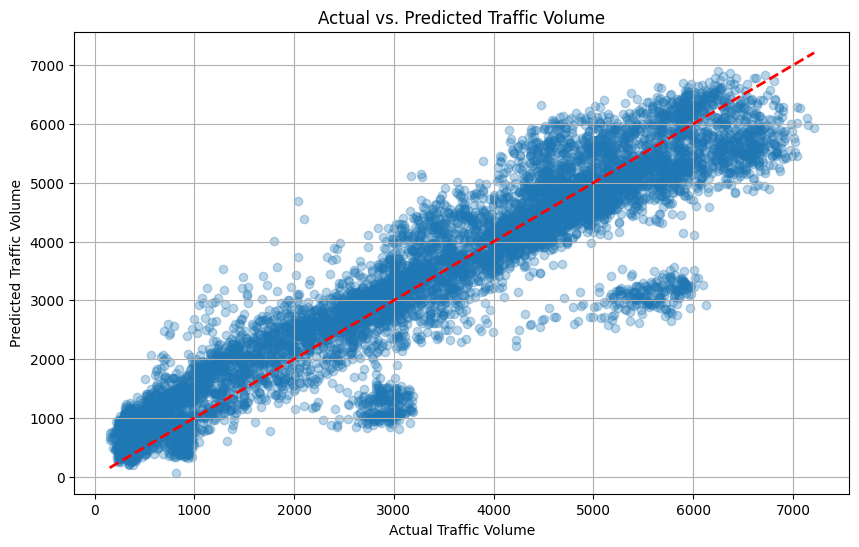

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred1, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Red dashed line for ideal prediction
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs. Predicted Traffic Volume")
plt.grid(True)
plt.show()

Overall, the plot visually confirms that the model captures the general trend of traffic volume but has room for improvement in predicting extreme values or reducing prediction errors across the board.



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize and train the Random Forest Regressor model
model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_estimators can be tuned
model2.fit(X_train, y_train)

# Make predictions on the test set
pred2 = model2.predict(X_test)

# Evaluate the model
mae2 = mean_absolute_error(y_test, pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, pred2))

print("Experiment 2 - Random Forest Regression")
print("MAE:", mae2)
print("RMSE:", rmse2)

Experiment 2 - Random Forest Regression
MAE: 374.47798189009154
RMSE: 550.6936664639267


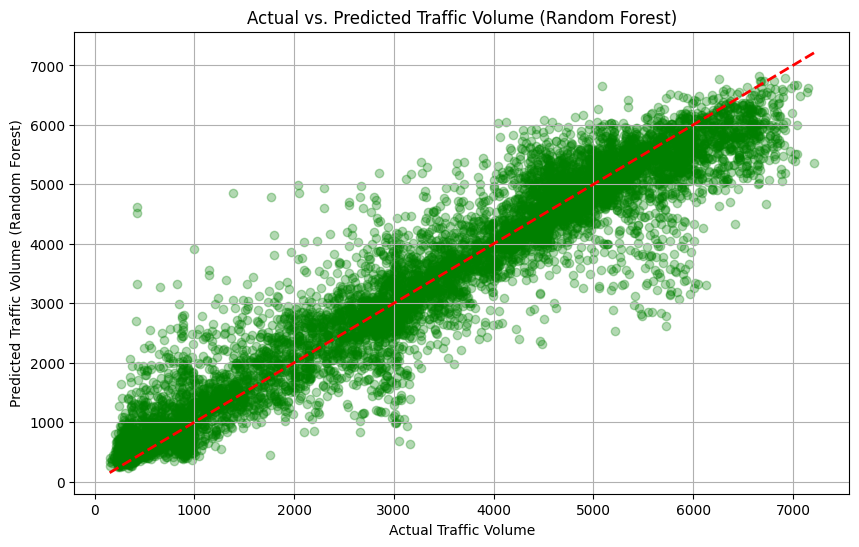

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred2, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Red dashed line for ideal prediction
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume (Random Forest)")
plt.title("Actual vs. Predicted Traffic Volume (Random Forest)")
plt.grid(True)
plt.show()

This plot indicates that the Random Forest model provides a more accurate and robust prediction of traffic volume compared to the Linear Regression model for this dataset.



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 15]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=3)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Initialize and train the Random Forest Regressor model with best parameters
model_optimized = RandomForestRegressor(n_estimators=grid.best_params_['n_estimators'],
                                        max_depth=grid.best_params_['max_depth'],
                                        random_state=42, n_jobs=-1)
model_optimized.fit(X_train, y_train)

# Make predictions on the test set
pred_optimized = model_optimized.predict(X_test)

# Evaluate the model
mae_optimized = mean_absolute_error(y_test, pred_optimized)
rmse_optimized = np.sqrt(mean_squared_error(y_test, pred_optimized))

print("Experiment 3 - Optimized Random Forest Regression")
print("MAE:", mae_optimized)
print("RMSE:", rmse_optimized)

Experiment 3 - Optimized Random Forest Regression
MAE: 377.8135059743326
RMSE: 544.8834595412984


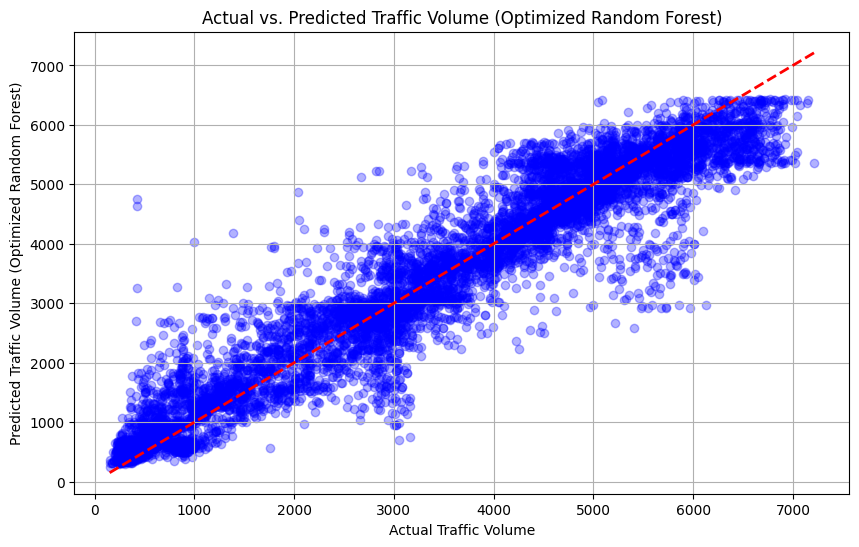

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_optimized, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Red dashed line for ideal prediction
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume (Optimized Random Forest)")
plt.title("Actual vs. Predicted Traffic Volume (Optimized Random Forest)")
plt.grid(True)
plt.show()

## Compare Model Performance


In [ ]:
import pandas as pd

# Create a dictionary to hold the metrics
metrics_data = {
    'Model': ['Linear Regression', 'Random Forest (Initial)', 'Random Forest (Optimized)'],
    'MAE': [mae1, mae2, mae_optimized],
    'RMSE': [rmse1, rmse2, rmse_optimized]
}

# Create the DataFrame
comparison_df = pd.DataFrame(metrics_data)

# Print the comparison table
print("\nModel Performance Comparison:")
print(comparison_df.set_index('Model'))


Model Performance Comparison:
                                  MAE        RMSE
Model                                            
Linear Regression          489.950261  684.420473
Random Forest (Initial)    374.477982  550.693666
Random Forest (Optimized)  377.813506  544.883460


From the `Model Performance Comparison` table:

- **Linear Regression**: Has the highest MAE (489.95) and RMSE (684.42).
- **Random Forest (Initial)**: Shows a significant improvement over Linear Regression with MAE (374.48) and RMSE (550.69).
- **Random Forest (Optimized)**: The MAE (377.81) is slightly higher than the initial Random Forest, but the RMSE (544.88) is slightly lower, indicating that while average error is marginally worse, larger errors are penalized less. However, the difference is very small.

**Conclusion**: The **Random Forest (Initial)** model performed the best overall with the lowest MAE (374.48), while the **Random Forest (Optimized)** model achieved a marginally better RMSE (544.88) but a slightly higher MAE. Both Random Forest models significantly outperformed the Linear Regression model, indicating that non-linear relationships and ensemble methods are more suitable for this dataset. The optimization with GridSearchCV did not yield a substantial improvement for MAE and only a slight improvement for RMSE within the tested hyperparameter range.

In [ ]:
pip install pandas mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 20.4 MB/s eta 0:00:00
